## Clustering

Al comenzar con el análisis exploratorio del dataset **`clustering.csv`**, realizamos una inspección preliminar para entender la estructura y calidad de los datos antes de aplicar técnicas de **`clustering`**. Se visualizó una muestra aleatoria de observaciones para obtener una impresión general del contenido y distribución de las variables.

Examinamos el **rango de valores** en cada columna, lo cual resulta útil para detectar posibles **`outliers`** o escalas dispares que podrían afectar los algoritmos basados en distancias. Además, se identificaron **valores faltantes** en ciertas categorías y la presencia de **filas duplicadas**, ambos aspectos que deben ser tenidos en cuenta durante el preprocesamiento para evitar sesgos o información redundante.

Por último, se construyeron histogramas para las distintas features con el objetivo de observar su **distribución univariada**. Esta visualización es clave para anticipar si será necesario aplicar transformaciones o normalizaciones, especialmente en métodos sensibles a la escala como **`K-Means`**.

Fragmento aleatorio de muestras


,A,B
475,538243,205298
3638,356265,117217
1292,812151,245409
4799,652325,155140
1070,563645,483100
1586,432232,612326
1752,451508,619873



Rango de valores de cada columna


,A,B
min,55608.0,25631.0
max,983609.0,984555.0



Categorías con valores faltantes
 Series([], )

Filas duplicadas: 0


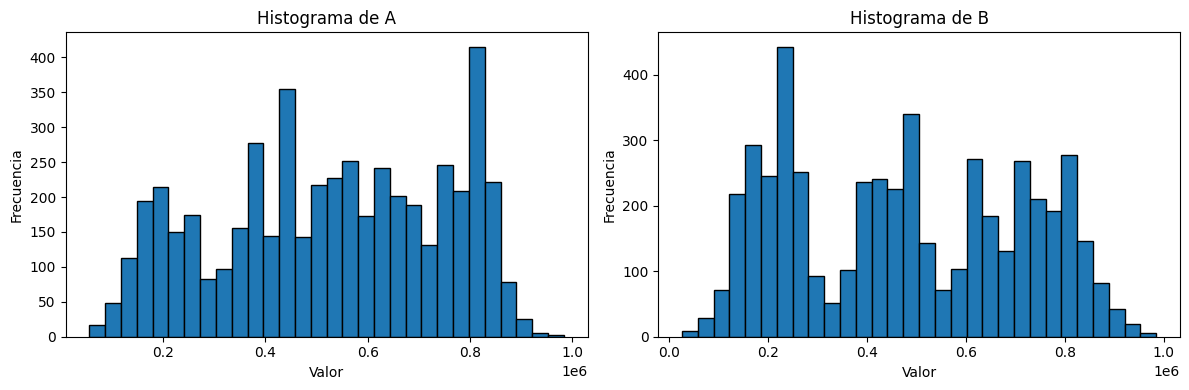

In [1]:
from src.visualization import view_data, plot_histograms
import pandas as pd
data = pd.read_csv('data\clustering.csv', index_col=0)

view_data(data)
plot_histograms(data)

Al analizar el rango de valores en las columnas **`A`** y **`B`**, observamos que ambas se encuentran contenidas en un intervalo amplio, aproximadamente entre `0` y `1e6`. Este rango tan extenso puede afectar negativamente el desempeño de algoritmos sensibles a la escala, por lo que es conveniente aplicar una transformación de **`estandarización`**.

En esta etapa no se detectaron **valores faltantes** ni **filas duplicadas**, lo cual simplifica el proceso de limpieza. Los histogramas iniciales confirmaron que las variables tienen distribuciones amplias pero acotadas dentro del rango mencionado.

Luego de aplicar la transformación estándar a ambas columnas, volvimos a visualizar los histogramas con el objetivo de evaluar si la nueva escala modifica drásticamente la forma de las distribuciones. Esta comparación es importante para entender si la transformación preserva la estructura informativa o si distorsiona significativamente los datos.

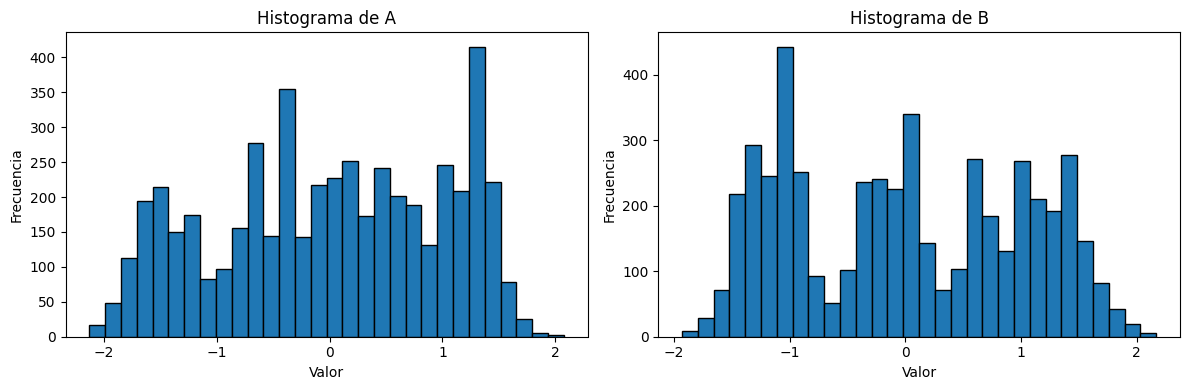

In [2]:
from src.preprocessing import standard_fit, standard_transform
media, std = standard_fit(data['A'])
data['A'] = standard_transform(data['A'], media, std)
media, std = standard_fit(data['B'])
data['B'] = standard_transform(data['B'], media, std)
plot_histograms(data)

Luego de aplicar la transformación estándar a las columnas **`A`** y **`B`**, observamos que los valores quedaron centrados alrededor de `0` y mayormente contenidos entre `-2` y `2`. Ahora los valores son mucho más manejables para los algoritmos de **`clustering`**. Es importante destacar que la forma de las distribuciones no se vio alterada por la transformación: los histogramas conservan la misma estructura que antes, lo que indica que la estandarización no distorsionó la información original.

Una vez transformados los datos, realizamos una visualización en el plano de las variables **`A`** y **`B`** para observar la distribución general de las muestras. Este paso nos permite tener una primera intuición visual sobre la posible presencia de agrupamientos naturales en los datos, y puede orientar la elección inicial del número de clusters.

Para complementar esta exploración, aplicamos el algoritmo **`K-Means`**, utilizando el método de inicialización **`KMeans++`** para elegir mejores posiciones iniciales de los centroides. Además, repetimos el algoritmo **15 veces con diferentes inicializaciones aleatorias**, y nos quedamos con la mejor corrida según la **menor inercia final**, lo que mejora la estabilidad y calidad del agrupamiento.

Luego, utilizamos el criterio de **`ganancias decrecientes`** (o “`método del codo`”) como estrategia para determinar una cantidad adecuada de clusters. Esto consiste en graficar la inercia total (**`L`**) en función de **`K`**, y analizar el punto a partir del cual las mejoras en el agrupamiento comienzan a volverse marginales. Esta combinación de análisis visual y cuantitativo nos da una base sólida para decidir cómo segmentar los datos.

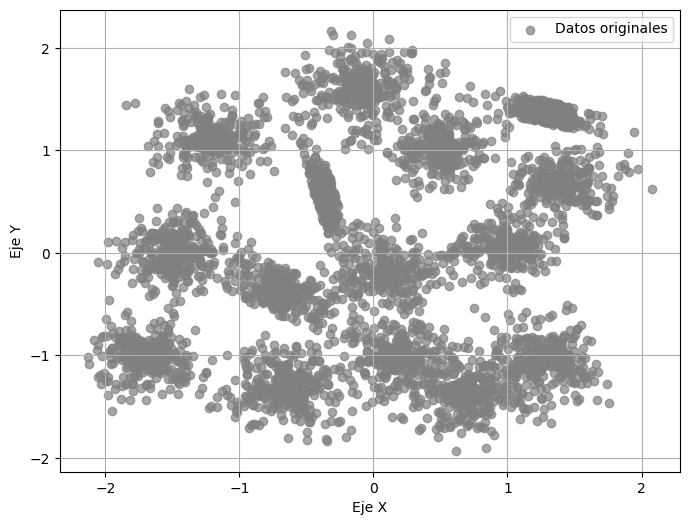

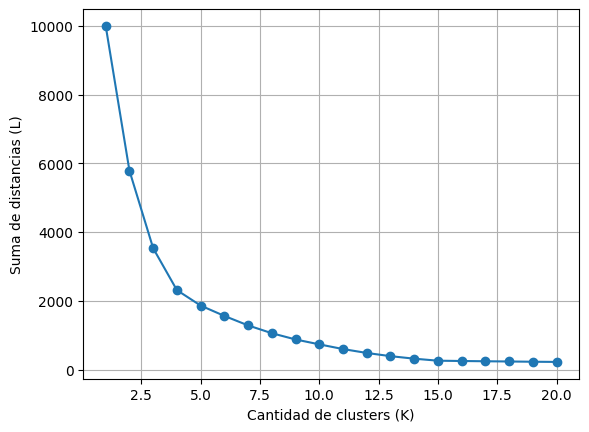

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,Cluster 18,Cluster 19,Cluster 20
K,1.0,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00,15.0,16.00,17.00,18.00,19.00,20.00
L,9996.0,5787.35,3529.44,2310.21,1861.27,1560.23,1284.46,1057.23,875.36,732.84,596.07,482.92,389.66,316.37,257.6,248.82,241.18,234.73,227.32,222.04


In [3]:
from src.visualization import plot_data, plot_elbow_method
from src.exploration import explore_kmeans
plot_data(data)
Ls = explore_kmeans(data, 20)
plot_elbow_method(Ls, "kmeans", 20)


La visualización de los datos nos permite identificar alrededor de **13 o más estructuras** diferenciadas entre sí, algo que también se refleja claramente en el método de **`ganancias decrecientes`**. A partir de **`K = 13`**, la mejora en la **`inercia total`** comienza a volverse marginal, y entre **K = 13, 14 y 15** la curva se aplana considerablemente. Por este motivo, seleccionamos **`K = 14`** como una opción razonable para avanzar con la segmentación.

A continuación, graficamos el conjunto de datos **`Xᵢ`**, coloreando los puntos según el cluster al que pertenecen y marcando además la posición de cada **centroide**. Esta visualización nos permite inspeccionar visualmente la distribución y separación de los clusters resultantes.

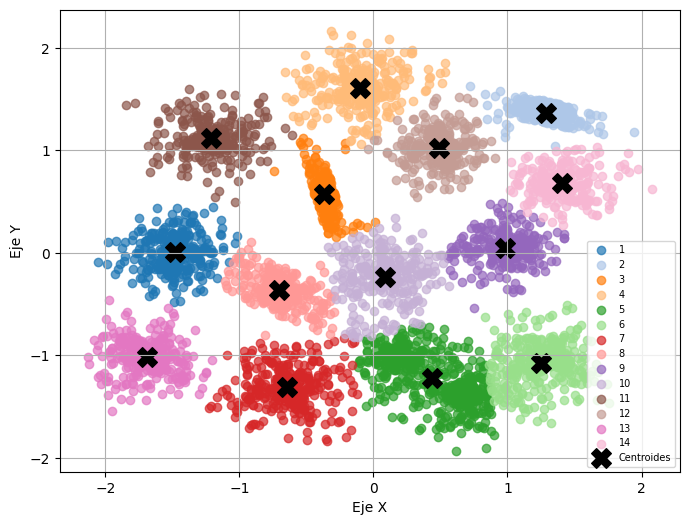

In [14]:
from src.visualization import plot_clusters
from src.clustering import kmeans
data_array = data.values  # Convertir DataFrame a array de NumPy

k = 14
model_kmeans = kmeans(data_array, n_clusters=k)
plot_clusters(data_array, model_kmeans, model_type="kmeans")

El método aplicado logra una separación bastante clara de las estructuras presentes en los datos, con clusters bien definidos y escasa superposición visual. Sin embargo, no todos los agrupamientos logran capturar la **forma real** de las distribuciones. Un ejemplo claro es el **cluster 3** (color naranja), que presenta una estructura alargada o elíptica, pero incorpora varios puntos que, visualmente, pertenecen a otras estructuras pero parecen estar a menor distancia de este centroide. Esto sugiere que **`K-Means`**, al utilizar particiones rígidas basadas en distancia al centroide, puede fallar en contextos donde la **forma del cluster no es esférica**.

A continuación, implementamos el algoritmo **`Gaussian Mixture Model (GMM)`** como una alternativa más flexible que permite capturar estructuras con formas elípticas. Aplicaremos también el criterio de **`ganancias decrecientes`**, esta vez en base a la **`log-verosimilitud`**, y utilizaremos una corrida previa de **K-Means** para inicializar la optimización.

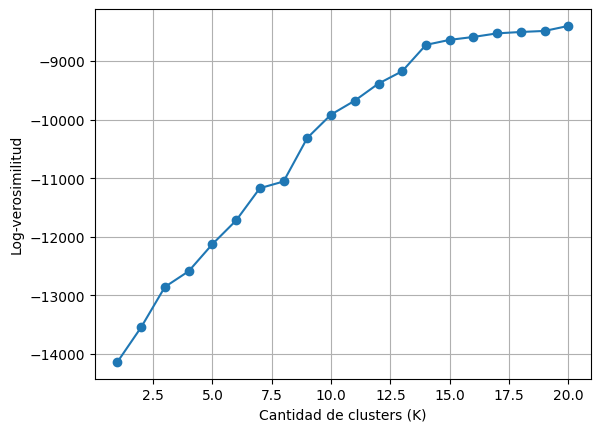

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,Cluster 18,Cluster 19,Cluster 20
K,1.00,2.00,3.00,4.00,5.0,6.00,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00,15.00,16.0,17.00,18.00,19.00,20.00
L,-14141.19,-13548.02,-12859.02,-12591.47,-12128.7,-11723.47,-11172.09,-11057.48,-10312.55,-9914.18,-9675.95,-9384.06,-9172.61,-8722.61,-8637.04,-8587.3,-8525.84,-8502.43,-8484.44,-8398.83


In [5]:
from src.exploration import explore_gmm

Ls = explore_gmm(data, 20)
plot_elbow_method(Ls, "gmm", 20)

La última mejora significativa en la **`log-verosimilitud`**, siguiendo el criterio de **`ganancias decrecientes`**, se observa alrededor de **`K = 14`**, coincidiendo con el valor elegido previamente para **`K-Means`**. Esta consistencia entre ambos métodos sugiere que existe una estructura latente en los datos que se refleja en diferentes enfoques de agrupamiento.

A partir de esta observación, utilizamos nuestra solución de **`K-Means`** con **`K = 14`** como inicialización para el algoritmo **`GMM`**, con el objetivo de comparar los resultados y analizar qué diferencias surgen al permitir **formas elípticas** y **probabilidades suaves** de pertenencia a cada cluster.

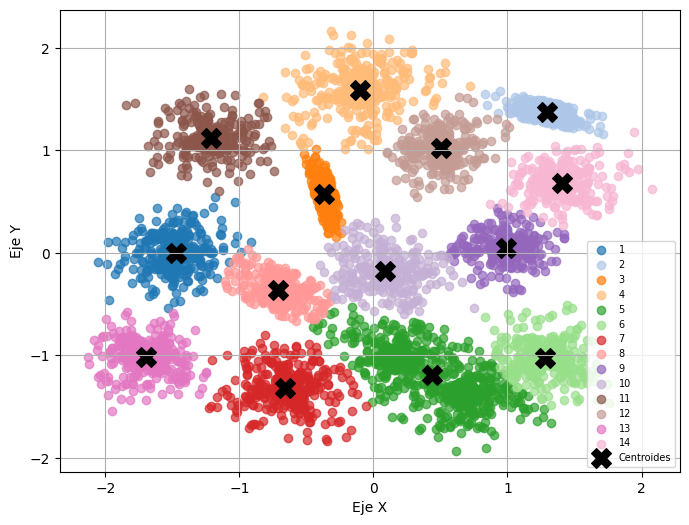

In [15]:
from src.clustering import GMM
model_gmm = GMM(
    data_array,
    n_components=k,
    means=model_kmeans.centroids,
    labels=model_kmeans.labels
)
plot_clusters(data_array, model_gmm, model_type="gmm")

Ahora, los **`clusters`** presentan formas más pronunciadas y mejor definidas. En particular, el grupo con forma elíptica que anteriormente incluía datos fuera de su estructura ahora aparece claramente segmentado, sin interferencias externas. En general, las **formas elípticas** se ven mucho mejor representadas, lo que refleja la ventaja de **`GMM`** frente a métodos basados únicamente en distancias radiales como **`K-Means`**.

Sin embargo, también observamos una limitación: en regiones donde los datos están muy próximos entre sí, aparecen puntos "intermedios" que son asignados a uno u otro cluster, aunque visualmente no exista una clara frontera que justifique esa clasificación. Esto resalta que, si bien el modelo puede lograr una buena **precisión estadística**, no siempre es posible validar visualmente al 100% la pertenencia de cada punto.

Para abordar esta limitación, implementamos el algoritmo **`DBSCAN`**, que tiene la capacidad de identificar estos puntos intermedios como **ruido** cuando no cumplen con los criterios de densidad. Trabajaremos sobre el mismo conjunto de datos y exploraremos el efecto de variar sus dos parámetros principales: `ε` (radio de vecindad) y `min_samples` (cantidad mínima de puntos para formar una zona densa). Para evaluar la calidad de cada configuración, usaremos la métrica **`silhouette_manual`**, que mide qué tan bien se separan los clusters entre sí y cuán compactos son, y aplicaremos un umbral de ruido del `5%` para evitar soluciones con demasiados puntos no asignados.

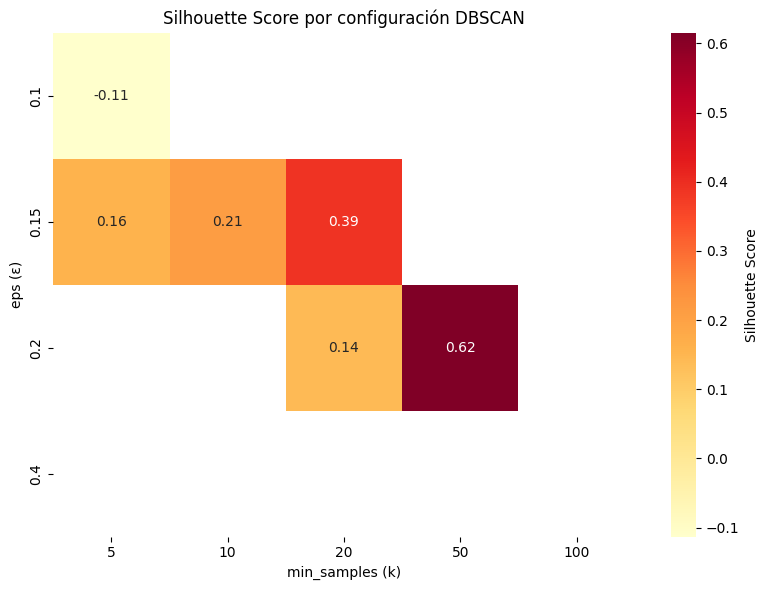

In [16]:
from src.visualization import plot_metric_dbscan
from src.exploration import explore_dbscan
eps = [0.1, 0.15, 0.2, 0.4]
k = [5, 10, 20, 50, 100]

tabla = explore_dbscan(data_array, eps, k, ruido_max=0.05)
plot_metric_dbscan(tabla)


Permitir solo un **5% de ruido** limitó las configuraciones viables del modelo. En el gráfico se observa que el mejor desempeño, según la métrica **`silhouette_manual`**, se obtuvo con los parámetros **ε = 0.2** y **min_samples = 50**. Esto refleja una combinación que maximiza la separación entre clusters y minimiza el ruido.

Procedemos a graficar los datos asignando colores y marcadores distintos para cada cluster, incluyendo el ruido como una categoría separada. Esto nos permitirá comparar visualmente los resultados de **`DBSCAN`** con los obtenidos previamente mediante **`GMM`** y **`K-Means`**, evaluando si las mejoras observadas en la métrica se traducen también en una segmentación más lógica e intuitiva de los datos.

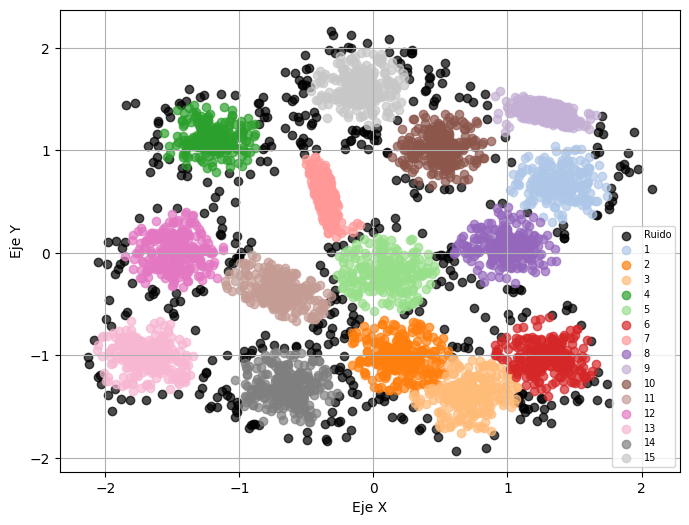

In [ ]:
from src.clustering import DBSCAN
DBSCAN_model = DBSCAN(data_array, eps=0.2, min_samples=50)
plot_clusters(data_array, DBSCAN_model, model_type="dbscan")

Este modelo introduce un **cluster adicional** y segmenta de manera precisa las estructuras principales. Los datos que no son distinguibles visualmente, a diferencia de los modelos anteriores, no se clasifican y se identifican como **ruido**, lo que refuerza la capacidad de **`DBSCAN`** para manejar estas situaciones.  

Sin embargo, los clusters con una **forma elíptica pronunciada**, que habían sido bien representados al usar **`GMM`**, ahora pierden nuevamente la representación perfecta en las puntas, un comportamiento similar al observado previamente con **`K-Means`**. Esto destaca una limitación de **`DBSCAN`** al trabajar con este tipo de geometrías, aunque sigue siendo una mejora significativa respecto a los métodos puramente radiales.

## Reduccion de Dimensionalidad
Para comenzar con el análisis del dataset de imágenes de dígitos manuscritos, cargamos los datos desde **`MNIST_dataset.csv`**. Este conjunto representa cada imagen como una fila con **784 valores**, correspondientes a los **28x28 píxeles** en escala de grises. La intensidad de gris de cada píxel está codificada como un valor numérico, lo que nos da una representación tabular de las imágenes.

Separaremos las features (valores de los píxeles) en una matriz **`X`**, y las etiquetas (el dígito representado en cada imagen) en un vector **`Y`**. Esta separación nos permite trabajar exclusivamente con los datos de entrada para aplicar técnicas de **`reducción de dimensionalidad`**, y luego utilizar las etiquetas solo con fines de validación y visualización de resultados.

In [1]:
df = pd.read_csv("data\MNIST_dataset.csv")
y = df['label'].values
X = df.drop(columns=['label']).values

Aplicamos el método de **`Análisis de Componentes Principales (PCA)`** con el objetivo de reducir la dimensionalidad del conjunto de imágenes preservando la mayor cantidad de información posible. Esta técnica busca identificar nuevas variables —los **`componentes principales`**— que capturan la mayor varianza de los datos originales, permitiendo una representación más compacta.

Para evaluar qué tan bien se conserva la información al reducir la dimensión, graficamos el **`error cuadrático medio de reconstrucción`** en función de la cantidad de componentes utilizados. Esta métrica nos indica qué tan diferente es la reconstrucción de una imagen comprimida respecto a la original, y nos permite visualizar el punto a partir del cual agregar más componentes ofrece **ganancias marginales** en calidad. Así, podemos balancear entre compresión y fidelidad de representación.

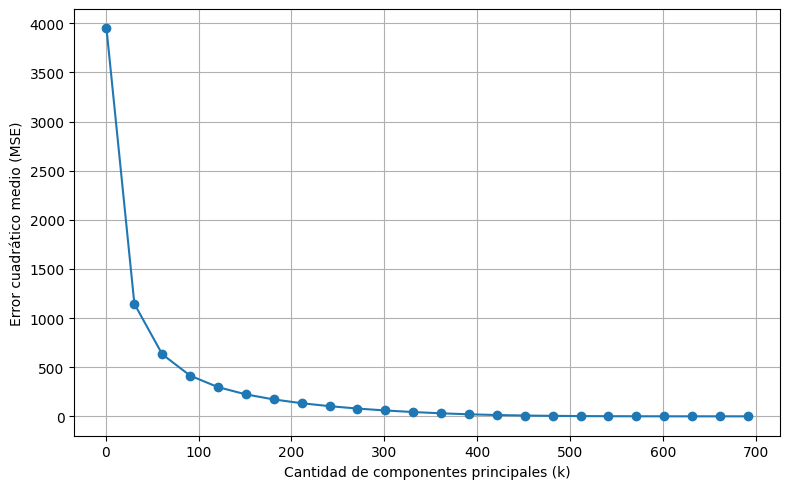

Error para k=1: 3948.578012698194
Error para k=31: 1145.3938241242515
Error para k=61: 631.4468817857189
Error para k=91: 414.01274321207603
Error para k=121: 297.16912972890964
Error para k=151: 223.21000313475102
Error para k=181: 171.8946589895619
Error para k=211: 133.49675400776857
Error para k=241: 103.27092882787754
Error para k=271: 79.12947896837785
Error para k=301: 59.43877531031305
Error para k=331: 43.508922871313125
Error para k=361: 30.679351589620712
Error para k=391: 20.61902463784556
Error para k=421: 13.257137709934241
Error para k=451: 8.12903446383782
Error para k=481: 4.738289539771705
Error para k=511: 2.5742103946156685
Error para k=541: 1.2682041796389523
Error para k=571: 0.5487797632995647
Error para k=601: 0.2080518680917777
Error para k=631: 0.0629637964535312
Error para k=661: 0.011682557170574776
Error para k=691: 0.0005463008861644036


In [17]:
from src.exploration import explore_pca
from src.visualization import plot_pca_errors

ks, errors = explore_pca(X, 700, step=30)
plot_pca_errors(ks, errors)
for i in range(len(ks)):
    print(f"Error para k={ks[i]}: {errors[i]}")

Para elegir una cantidad adecuada de **`componentes principales`**, analizamos cómo disminuye el **`error cuadrático medio de reconstrucción`** al aumentar el número de componentes. Observamos que las mejoras son significativas al pasar de pocas componentes hasta alrededor de **211**, punto en el que el **MSE** se reduce considerablemente a **133.50**. A partir de este valor, las ganancias en la reducción del error se vuelven marginales, mientras que la complejidad del modelo sigue aumentando.  

En función de este comportamiento, seleccionamos **`K = 210`** como un buen compromiso entre reducción de dimensionalidad y calidad de reconstrucción. Este valor permite capturar la mayor parte de la información esencial del conjunto de datos, logrando errores bajos sin necesidad de mantener la totalidad de las 784 dimensiones originales.  

Usando esta configuración, reconstruimos las primeras 10 imágenes del dataset y las comparamos visualmente con sus versiones originales. Esta comparación valida que, aunque existe una leve pérdida de detalle, las imágenes conservan su forma global y son fácilmente reconocibles, confirmando la eficacia de esta selección.  

c:\Users\bianc\Machine\Bianchi_Martin_TP4\src\visualization.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


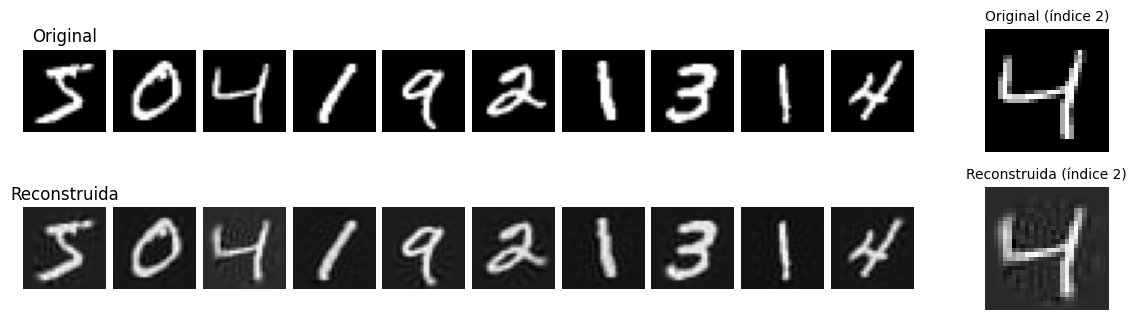

In [2]:
from src.dreduction import pca_transform_reconstruct
from src.visualization import plot_reconstructions
_, X_reconstructed = pca_transform_reconstruct(X, 210)
plot_reconstructions(X, X_reconstructed)

Luego de establecer **`K = 210`** como una dimensión adecuada en el enfoque de **PCA**, pasamos a entrenar un modelo **`autoencoder variacional (VAE)`**, con el objetivo de comparar su capacidad de reconstrucción utilizando la misma cantidad de información comprimida.

Para ello, primero preparamos el dataset normalizando los valores de píxel al rango `[0, 1]` mediante una división por **255**, y lo separamos en dos subconjuntos: **`entrenamiento`**, que se utiliza para ajustar los parámetros del modelo, y **`validación`**, con el que se evalúa su capacidad de generalización y se ajustan los hiperparámetros.

La arquitectura del VAE incluye una red **encoder** que proyecta las imágenes al espacio latente, y una red **decoder** que intenta reconstruirlas a partir de esa representación comprimida. Fijamos la dimensión del espacio latente en **`210`**, para mantener una base de comparación directa con el análisis previo de PCA.

Entrenamos distintas variantes del modelo modificando algunos de sus **`hiperparámetros clave`**, como la cantidad de neuronas en las capas ocultas (`hidden_dims`), la **tasa de aprendizaje** (`lr`), el **tamaño del batch** (`batch_size`) y el **término de regularización L2**. Estas variaciones nos permiten explorar cómo influyen tanto en la calidad de reconstrucción como en la estabilidad del proceso de entrenamiento.

In [21]:
from src.preprocessing import train_test_split
from src.exploration import explore_vaes

X_train, y_train, X_val, y_val = train_test_split(X, y, test_size=0.2)

X_train = X_train / 255.0
X_val = X_val / 255.0

configs = [
    {"hidden_dims": [512, 256], "latent_dim": 210, "lr": 1e-2, "L2": 1e-5, "batch_size": 64},
    {"hidden_dims": [256, 128], "latent_dim": 210, "lr": 1e-3, "L2": 1e-4, "batch_size": 128},
    {"hidden_dims": [256], "latent_dim": 210, "lr": 1e-3, "L2": 1e-4, "batch_size": 128},
    {"hidden_dims": [512], "latent_dim": 210, "lr": 1e-2, "L2": 1e-3, "batch_size": 128}
]
vae = explore_vaes(X_train, X_val, configs, epochs=10, early_stopping=True)


Capas: [512, 256] | MSE validación: 0.0357
Capas: [256, 128] | MSE validación: 0.0180
Capas: [256] | MSE validación: 0.0151
Capas: [512] | MSE validación: 0.0583

=== Mejor modelo ===
Config: {'hidden_dims': [256], 'latent_dim': 210, 'lr': 0.001, 'L2': 0.0001, 'batch_size': 128}
Capas: [512] | MSE validación: 0.0151


Los resultados obtenidos muestran que el **`error cuadrático medio de reconstrucción (MSE)`** en validación se redujo de forma notable en comparación con **PCA**, donde el valor para **`K = 210`** era de aproximadamente **133.50**. En cambio, todas las configuraciones del **`VAE`** evaluadas lograron errores menores a **1**, lo que representa una mejora significativa en términos de calidad de reconstrucción.

Entre las variantes probadas, la mejor correspondió a una arquitectura con **una única capa oculta de 256 neuronas**, combinada con una **tasa de aprendizaje baja**, una **regularización L2 moderada** y **batch size** de 128. Esta configuración alcanzó un **`MSE de validación de 0.0145`**, mostrando que incluso una red relativamente compacta es capaz de capturar de manera muy eficiente la estructura del dataset en el espacio latente.

Dado que todos los modelos entrenados hasta el momento comparten la misma **`dimensión latente (210)`**, el siguiente paso será analizar cómo impacta en la calidad de reconstrucción la cantidad de dimensiones utilizadas. Esto permitirá entender si es posible lograr un rendimiento similar utilizando una representación aún más comprimida, o si por el contrario es necesario aumentar la capacidad del espacio latente para evitar pérdida de información.

Capas: [256] | MSE validación: 0.0379
Capas: [256] | MSE validación: 0.0141
Capas: [256] | MSE validación: 0.0150

=== Mejor modelo ===
Config: {'hidden_dims': [256], 'latent_dim': 30, 'lr': 0.001, 'L2': 0.0001, 'batch_size': 128}
Capas: [256] | MSE validación: 0.0141


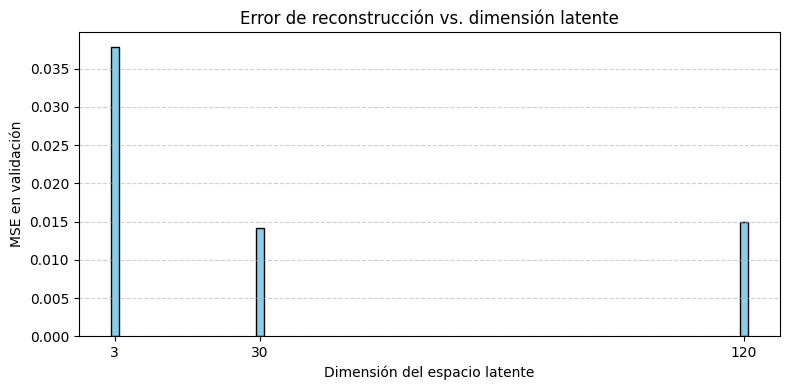

In [6]:
configs = [
    {"hidden_dims": [256], "latent_dim": 3, "lr": 1e-3, "L2": 1e-4, "batch_size": 128},
    {"hidden_dims": [256], "latent_dim": 30, "lr": 1e-3, "L2": 1e-4, "batch_size": 128},
    {"hidden_dims": [256], "latent_dim": 120, "lr": 1e-3, "L2": 1e-4, "batch_size": 128},
]
vae = explore_vaes(X_train, X_val, configs, epochs=10, early_stopping=True, plot_latent_mse=True)

Evaluamos distintas configuraciones, desde una latente extremadamente reducida (**`latent_dim = 3`**) hasta una representación más extensa de **120 dimensiones**, observando cómo varía el **`error cuadrático medio de reconstrucción`** en el conjunto de validación.

Como era esperable, al usar solo **3 dimensiones**, el error de reconstrucción aumenta de forma notable en comparación con el resto de las configuraciones. Sin embargo, incluso este valor sigue siendo **sustancialmente menor** al obtenido con **`PCA`** utilizando más de 200 componentes. Esto evidencia que, aunque el VAE sufre una pérdida considerable de información en ese caso extremo, sigue siendo capaz de generar reconstrucciones razonables con representaciones latentes muy comprimidas. Esta diferencia se explica porque, a diferencia de **`PCA`**, el VAE no se limita a capturar combinaciones lineales de las variables originales, sino que aprende **representaciones no lineales** más compactas y adaptadas a la estructura de los datos.

A partir de **`latent_dim = 30`**, el error se estabiliza y las mejoras se vuelven marginales. De hecho, el mejor desempeño se obtuvo precisamente con esta configuración, lo que indica que con esa cantidad de dimensiones ya se capta toda la información relevante para la tarea de reconstrucción. Al aumentar la complejidad —ya sea agregando más dimensiones o más capas ocultas— no se observa una mejora en la calidad, e incluso puede haber un **ligero deterioro** del rendimiento, posiblemente debido a un mayor riesgo de **`overfitting`** o dificultades en la optimización.

En conjunto, estos resultados muestran que el **`VAE`** es capaz de aprender una codificación **más eficiente y expresiva con mucha mas reducción** que la que ofrece **`PCA`**, logrando errores similares o mejores con una fracción de la dimensionalidad.

Una vez desarrollado el **`VAE`**, compare la calidad de las imágenes reconstruidas con las obtenidas mediante **`PCA`** en el inciso anterior, utilizando 10 imágenes tomadas aleatoriamente del conjunto de validación del VAE.

Capas: [256] | MSE validación: 0.0149

=== Mejor modelo ===
Config: {'hidden_dims': [256], 'latent_dim': 210, 'lr': 0.001, 'L2': 0.0001, 'batch_size': 128}
Capas: [256] | MSE validación: 0.0149


c:\Users\bianc\Machine\Bianchi_Martin_TP4\src\visualization.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


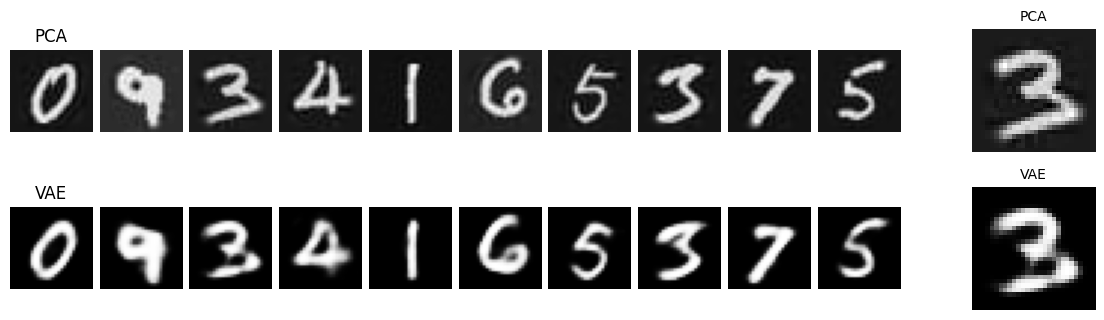

In [3]:
vae_recon = vae.reconstruct(X_val)
_, pca_recon = pca_transform_reconstruct(X_val, 210)
plot_reconstructions(pca_recon, vae_recon, titles=["PCA", "VAE"])

En la imagen se comparan las reconstrucciones generadas por **`PCA`** (fila superior) y por el **`VAE`** (fila inferior), utilizando las mismas 10 imágenes del conjunto de validación. Ambas técnicas logran preservar la forma general de los dígitos, pero se aprecian diferencias claras en la calidad de los resultados.

Las reconstrucciones del **VAE** presentan bordes más definidos, contornos suaves y una mayor fidelidad a la estructura del dígito original. En contraste, las imágenes generadas por **PCA** muestran un mayor nivel de ruido, distorsiones y pérdida de detalle fino, especialmente en digitos como el '3' que muestra una figura mucha menos redonda y fina, y por sobre todo en el fondo negro.

Esta comparación visual refuerza el análisis cuantitativo anterior: a pesar de utilizar una **representación latente mucho más compacta**, el **VAE** logra reconstrucciones **más limpias y naturales**, gracias a su capacidad de modelar relaciones **`no lineales`** y capturar mejor la estructura subyacente del dataset.